# Лабораторная работа №4
## Пространственные вращения: матрицы Эйлера, формула Родрига, параметры Родрига-Гамильтона и кватернионы

В этой работе по материалам `04.pdf` рассматриваются четыре способа задания пространственных вращений.
Вначале используется композиция элементарных матриц вращения, затем матричная форма формулы Родрига,
после этого вращения через параметры Родрига-Гамильтона и через кватернионы, а в конце показывается
вращение вокруг внешней оси, не проходящей через начало координат.

Все рисунки строятся в объектно-ориентированном интерфейсе `matplotlib`, с одинаковым масштабом осей,
сеткой и достаточно крупным размером изображения. Для интерактивных примеров используются ползунки
`ipywidgets.interact`.


In [1]:
import numpy as np
from ipywidgets import interact
from matplotlib.figure import Figure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial.transform import Rotation


DPI = 200
FIGSIZE_3D = (7.0, 7.0)

np.set_printoptions(suppress=True, precision=2)


def normalize(vector):
    vector = np.asarray(vector, dtype=np.float64)
    norm = np.linalg.norm(vector)
    if np.isclose(norm, 0.0):
        raise ValueError("Нулевой вектор нельзя нормировать.")
    return vector / norm


def translate_points(points, shift):
    points = np.asarray(points, dtype=np.float64)
    shift = np.asarray(shift, dtype=np.float64)
    return points + shift


def rotation_matrix_x(angle_rad):
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array(
        [
            [1.0, 0.0, 0.0],
            [0.0, c, -s],
            [0.0, s, c],
        ],
        dtype=np.float64,
    )


def rotation_matrix_y(angle_rad):
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array(
        [
            [c, 0.0, s],
            [0.0, 1.0, 0.0],
            [-s, 0.0, c],
        ],
        dtype=np.float64,
    )


def rotation_matrix_z(angle_rad):
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    return np.array(
        [
            [c, -s, 0.0],
            [s, c, 0.0],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )


def apply_matrix(points, matrix):
    points = np.asarray(points, dtype=np.float64)
    matrix = np.asarray(matrix, dtype=np.float64)
    return points @ matrix.T


def rodrigues_matrix(axis, angle_rad):
    axis = normalize(axis)
    ax, ay, az = axis
    skew = np.array(
        [
            [0.0, -az, ay],
            [az, 0.0, -ax],
            [-ay, ax, 0.0],
        ],
        dtype=np.float64,
    )
    identity = np.eye(3, dtype=np.float64)
    return identity + np.sin(angle_rad) * skew + (1.0 - np.cos(angle_rad)) * (skew @ skew)


def rotate_points_rodrigues_hamilton(points, axis, angle_rad):
    axis = normalize(axis)
    points = np.asarray(points, dtype=np.float64)
    lambda_0 = np.cos(angle_rad / 2.0)
    lam = np.sin(angle_rad / 2.0) * axis
    return points + 2.0 * lambda_0 * np.cross(lam, points) + 2.0 * np.cross(lam, np.cross(lam, points))


def quaternion_conjugate(quaternion):
    quaternion = np.asarray(quaternion, dtype=np.float64)
    return np.array(
        [quaternion[0], -quaternion[1], -quaternion[2], -quaternion[3]],
        dtype=np.float64,
    )


def quaternion_multiply(q1, q2):
    w1, x1, y1, z1 = np.asarray(q1, dtype=np.float64)
    w2, x2, y2, z2 = np.asarray(q2, dtype=np.float64)
    return np.array(
        [
            w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2,
            w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2,
            w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2,
            w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2,
        ],
        dtype=np.float64,
    )


def quaternion_from_axis_angle(axis, angle_rad):
    axis = normalize(axis)
    half = angle_rad / 2.0
    return np.array(
        [np.cos(half), *(np.sin(half) * axis)],
        dtype=np.float64,
    )


def rotate_points_quaternion(points, axis, angle_rad):
    points = np.asarray(points, dtype=np.float64)
    q = quaternion_from_axis_angle(axis, angle_rad)
    q = q / np.linalg.norm(q)
    q_conj = quaternion_conjugate(q)
    rotated = np.empty_like(points, dtype=np.float64)
    for index, point in enumerate(points):
        pure = np.array([0.0, point[0], point[1], point[2]], dtype=np.float64)
        value = quaternion_multiply(quaternion_multiply(q, pure), q_conj)
        rotated[index] = value[1:]
    return rotated


def rotate_about_axis_through_point(points, axis_point, axis_direction, angle_rad, method="rodrigues"):
    points = np.asarray(points, dtype=np.float64)
    axis_point = np.asarray(axis_point, dtype=np.float64)
    shifted = points - axis_point
    if method == "rodrigues":
        rotated = apply_matrix(shifted, rodrigues_matrix(axis_direction, angle_rad))
    elif method == "quaternion":
        rotated = rotate_points_quaternion(shifted, axis_direction, angle_rad)
    else:
        raise ValueError("Неизвестный способ вращения.")
    return rotated + axis_point


def edges_from_faces(faces):
    edges = set()
    for face in faces:
        for start, stop in zip(face, face[1:] + face[:1]):
            edges.add(tuple(sorted((start, stop))))
    return sorted(edges)


def padded_limits_3d(points, pad_ratio=0.15, min_pad=0.5):
    points = np.asarray(points, dtype=np.float64)
    minima = np.min(points, axis=0)
    maxima = np.max(points, axis=0)
    center = 0.5 * (minima + maxima)
    span = np.max(maxima - minima)
    half_size = max(0.5 * span + pad_ratio * span, min_pad)
    return (
        (center[0] - half_size, center[0] + half_size),
        (center[1] - half_size, center[1] + half_size),
        (center[2] - half_size, center[2] + half_size),
    )


def configure_3d_axes(ax, points, title, elev=18, azim=-60, vertical_axis="y"):
    xlim, ylim, zlim = padded_limits_3d(points)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    ax.set_box_aspect((1.0, 1.0, 1.0))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    ax.grid(True)
    try:
        ax.view_init(elev=elev, azim=azim, vertical_axis=vertical_axis)
    except TypeError:
        ax.view_init(elev=elev, azim=azim)
    draw_coordinate_axes(ax, xlim, ylim, zlim)
    return xlim, ylim, zlim


def make_3d_figure(points, title, figsize=FIGSIZE_3D, dpi=DPI, elev=18, azim=-60, vertical_axis="y"):
    fig = Figure(figsize=figsize, dpi=dpi, layout="constrained")
    ax = fig.add_subplot(1, 1, 1, projection="3d")
    limits = configure_3d_axes(ax, points, title=title, elev=elev, azim=azim, vertical_axis=vertical_axis)
    return fig, ax, limits


def draw_coordinate_axes(ax, xlim, ylim, zlim):
    x0, x1 = xlim
    y0, y1 = ylim
    z0, z1 = zlim
    ax.quiver(x0, 0.0, 0.0, x1 - x0, 0.0, 0.0, color="red", arrow_length_ratio=0.05, linewidth=1.1)
    ax.quiver(0.0, y0, 0.0, 0.0, y1 - y0, 0.0, color="green", arrow_length_ratio=0.05, linewidth=1.1)
    ax.quiver(0.0, 0.0, z0, 0.0, 0.0, z1 - z0, color="blue", arrow_length_ratio=0.05, linewidth=1.1)


def add_polyhedron(ax, vertices, faces, facecolor="white", edgecolor="black", alpha=0.20, linewidth=1.2):
    vertices = np.asarray(vertices, dtype=np.float64)
    collection = Poly3DCollection(
        [vertices[np.asarray(face, dtype=np.int64)] for face in faces],
        facecolors=facecolor,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
    )
    ax.add_collection3d(collection)
    for edge in edges_from_faces(faces):
        segment = vertices[list(edge)]
        ax.plot(segment[:, 0], segment[:, 1], segment[:, 2], color=edgecolor, linewidth=linewidth)


def annotate_vertices(ax, vertices, color="black", dx=0.05, dy=0.05, dz=0.05):
    vertices = np.asarray(vertices, dtype=np.float64)
    for index, point in enumerate(vertices):
        ax.scatter([point[0]], [point[1]], [point[2]], color=color, s=18)
        ax.text(point[0] + dx, point[1] + dy, point[2] + dz, str(index), color=color)


def draw_axis_line(ax, point, direction, limits, color="crimson", label="ось"):
    point = np.asarray(point, dtype=np.float64)
    direction = normalize(direction)
    xlim, ylim, zlim = limits
    half_size = max(xlim[1] - xlim[0], ylim[1] - ylim[0], zlim[1] - zlim[0])
    t_values = np.array([-half_size, half_size], dtype=np.float64)
    line = point + np.outer(t_values, direction)
    ax.plot(line[:, 0], line[:, 1], line[:, 2], color=color, linestyle="--", linewidth=1.6)
    anchor = point + 0.55 * half_size * direction
    ax.text(anchor[0], anchor[1], anchor[2], label, color=color)


def cleaned(points, digits=2):
    values = np.round(np.asarray(points, dtype=np.float64), digits)
    values[np.isclose(values, 0.0)] = 0.0
    return values


## Задание 1. Призма и композиция элементарных поворотов

В первом задании используется призма из методички и композиция двух элементарных вращений.
Для поворота вокруг осей координат применяются стандартные матрицы:

$$
R_x(\theta)=
\begin{pmatrix}
1 & 0 & 0 \\
0 & \cos\theta & -\sin\theta \\
0 & \sin\theta & \cos\theta
\end{pmatrix},
\quad
R_y(\theta)=
\begin{pmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta
\end{pmatrix},
\quad
R_z(\theta)=
\begin{pmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{pmatrix}.
$$

По данным таблиц 8-10 из `04.pdf` видно, что сначала нужен поворот на $90^\circ$ вокруг оси $Oy$,
а затем поворот результата на $90^\circ$ вокруг оси $Oz$.


In [2]:
PRISM_VERTICES = np.array(
    [
        [1.0, 0.0, 0.0],
        [1.0, 0.0, 1.0],
        [2.0, 0.0, 1.0],
        [3.0, 2.0, 1.0],
        [0.0, 2.0, 1.0],
        [2.0, 0.0, 0.0],
        [3.0, 2.0, 0.0],
        [0.0, 2.0, 0.0],
    ],
    dtype=np.float64,
)

PRISM_FACES = [
    [0, 1, 2, 5],
    [5, 2, 3, 6],
    [6, 3, 4, 7],
    [7, 4, 1, 0],
    [1, 2, 3, 4],
    [0, 5, 6, 7],
]

PRISM_Y90_TABLE = np.array(
    [
        [0.0, 0.0, -1.0],
        [1.0, 0.0, -1.0],
        [1.0, 0.0, -2.0],
        [1.0, 2.0, -3.0],
        [1.0, 2.0, 0.0],
        [0.0, 0.0, -2.0],
        [0.0, 2.0, -3.0],
        [0.0, 2.0, 0.0],
    ],
    dtype=np.float64,
)

PRISM_Y90_Z90_TABLE = np.array(
    [
        [0.0, 0.0, -1.0],
        [0.0, 1.0, -1.0],
        [0.0, 1.0, -2.0],
        [-2.0, 1.0, -3.0],
        [-2.0, 1.0, 0.0],
        [0.0, 0.0, -2.0],
        [-2.0, 0.0, -3.0],
        [-2.0, 0.0, 0.0],
    ],
    dtype=np.float64,
)


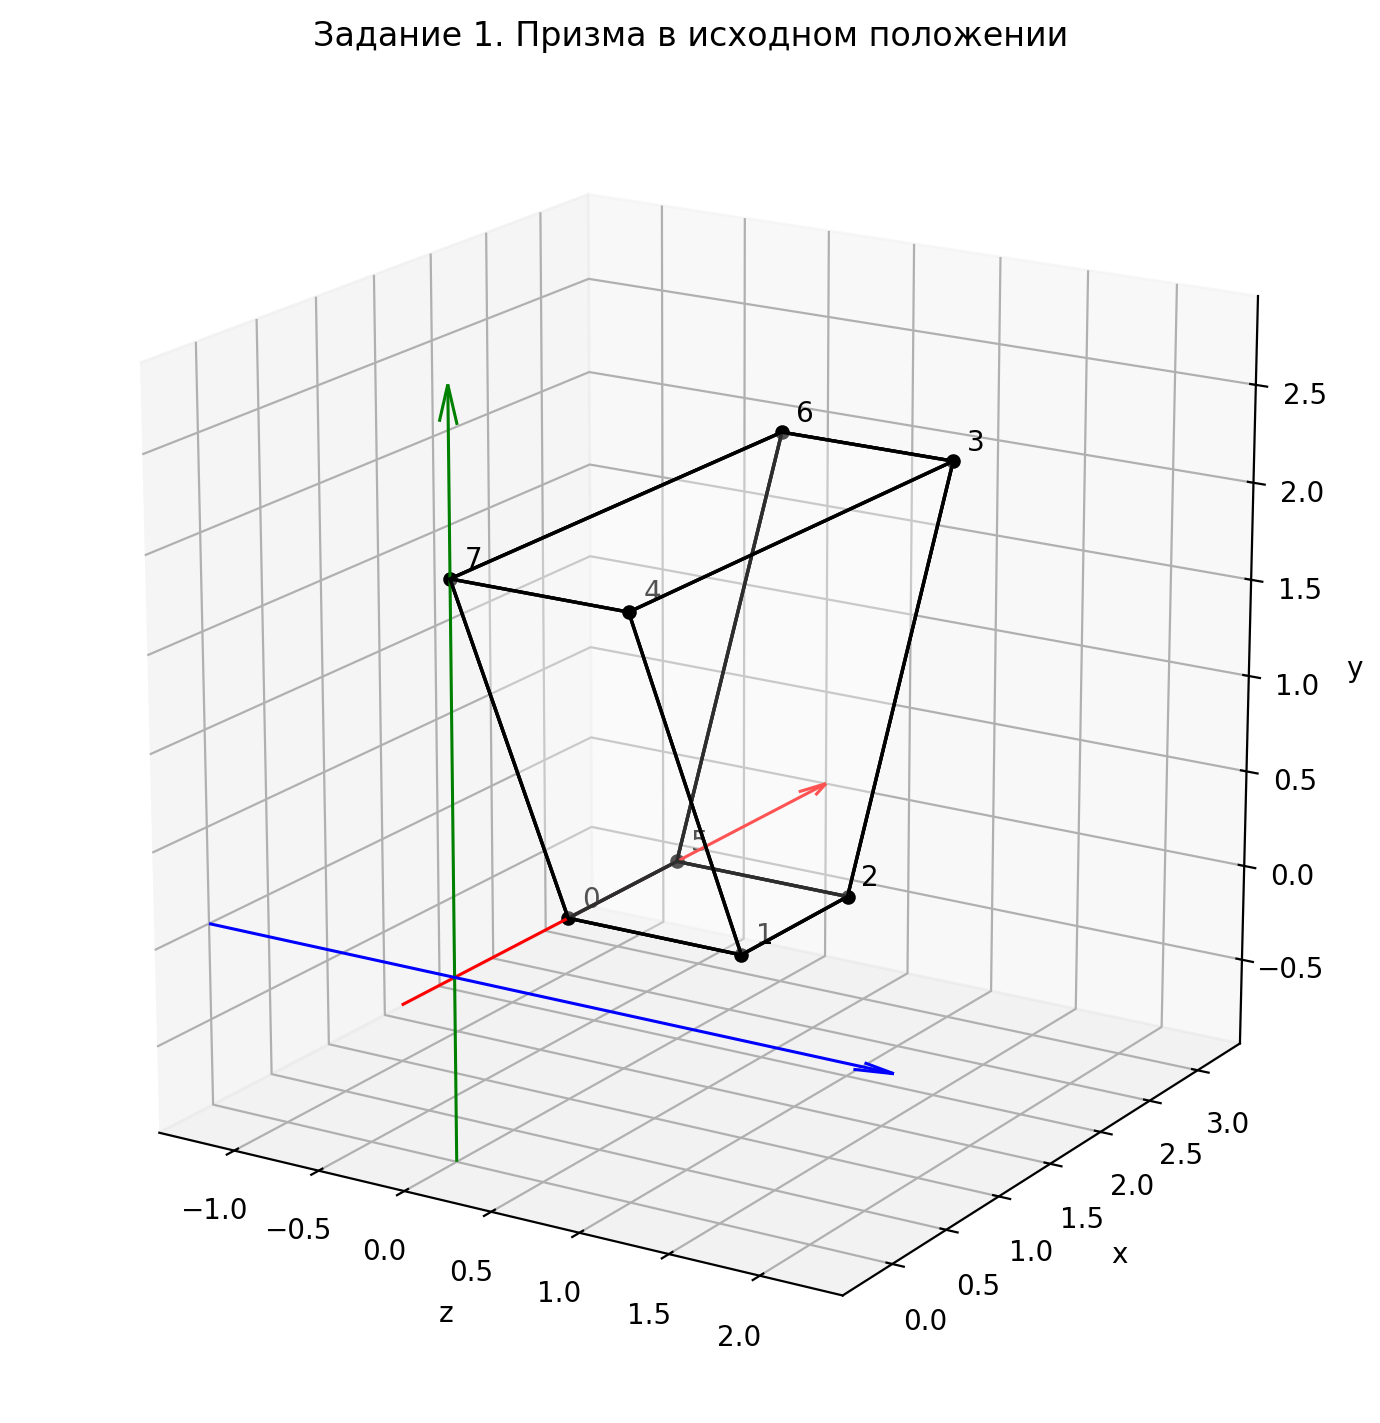

In [20]:
fig_prism_original, ax_prism_original, prism_limits = make_3d_figure(
    PRISM_VERTICES,
    title="Задание 1. Призма в исходном положении",
    elev=18,
    azim=-58,
)
add_polyhedron(ax_prism_original, PRISM_VERTICES, PRISM_FACES, facecolor="white", edgecolor="black", alpha=0.18)
annotate_vertices(ax_prism_original, PRISM_VERTICES)
fig_prism_original


In [21]:
angle_90 = np.deg2rad(90.0)

R_y_manual = rotation_matrix_y(angle_90)
R_y_scipy = Rotation.from_euler("y", 90.0, degrees=True).as_matrix()

print("Матрица поворота вокруг Oy на 90° (ручная):")
print(cleaned(R_y_manual))
print()
print("Матрица поворота вокруг Oy на 90° (SciPy):")
print(cleaned(R_y_scipy))
print()
print("Максимальное отличие между матрицами:", np.max(np.abs(R_y_manual - R_y_scipy)))


Матрица поворота вокруг Oy на 90° (ручная):
[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]]

Матрица поворота вокруг Oy на 90° (SciPy):
[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]]

Максимальное отличие между матрицами: 1.6081226496766364e-16


In [22]:
prism_y90_manual = apply_matrix(PRISM_VERTICES, R_y_manual)
prism_y90_scipy = Rotation.from_euler("y", 90.0, degrees=True).apply(PRISM_VERTICES)

print("Координаты после поворота вокруг Oy на 90°:")
print(cleaned(prism_y90_manual))
print()
print("Разность с таблицей 9:")
print(cleaned(prism_y90_manual - PRISM_Y90_TABLE, digits=10))
print()
print("Максимальное отличие ручного способа и SciPy:", np.max(np.abs(prism_y90_manual - prism_y90_scipy)))


Координаты после поворота вокруг Oy на 90°:
[[ 0.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -2.]
 [ 1.  2. -3.]
 [ 1.  2.  0.]
 [ 0.  0. -2.]
 [ 0.  2. -3.]
 [ 0.  2.  0.]]

Разность с таблицей 9:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Максимальное отличие ручного способа и SciPy: 4.82436794902991e-16


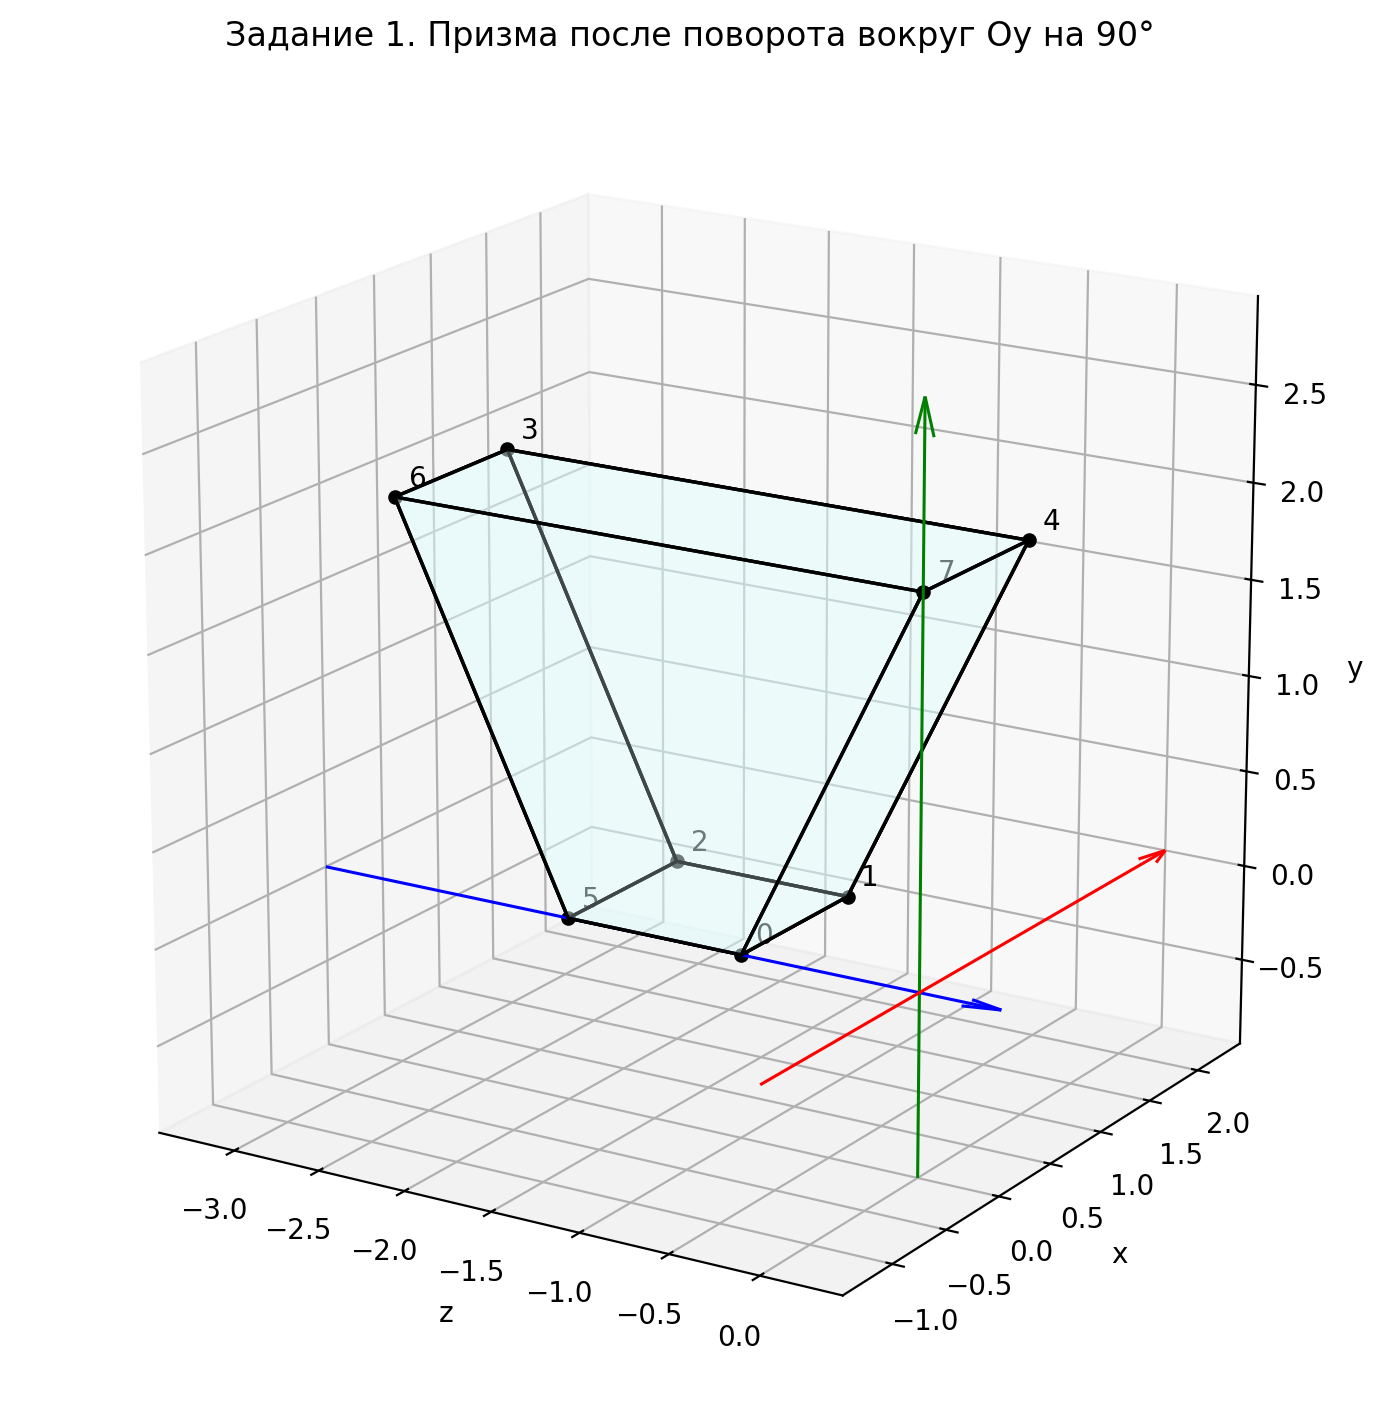

In [23]:
fig_prism_y, ax_prism_y, prism_y_limits = make_3d_figure(
    prism_y90_manual,
    title="Задание 1. Призма после поворота вокруг Oy на 90°",
    elev=18,
    azim=-58,
)
add_polyhedron(ax_prism_y, prism_y90_manual, PRISM_FACES, facecolor="lightcyan", edgecolor="black", alpha=0.28)
annotate_vertices(ax_prism_y, prism_y90_manual)
fig_prism_y


In [24]:
R_z_manual = rotation_matrix_z(angle_90)
R_zy_manual = R_z_manual @ R_y_manual

rotation_y = Rotation.from_euler("y", 90.0, degrees=True)
rotation_z = Rotation.from_euler("z", 90.0, degrees=True)
rotation_zy_scipy = rotation_z * rotation_y

prism_yz_manual = apply_matrix(PRISM_VERTICES, R_zy_manual)
prism_yz_scipy = rotation_zy_scipy.apply(PRISM_VERTICES)

print("Координаты после последовательности Oy(90°), затем Oz(90°):")
print(cleaned(prism_yz_manual))
print()
print("Разность с таблицей 10:")
print(cleaned(prism_yz_manual - PRISM_Y90_Z90_TABLE, digits=10))
print()
print("Максимальное отличие ручного способа и SciPy:", np.max(np.abs(prism_yz_manual - prism_yz_scipy)))


Координаты после последовательности Oy(90°), затем Oz(90°):
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 0.  1. -2.]
 [-2.  1. -3.]
 [-2.  1.  0.]
 [ 0.  0. -2.]
 [-2.  0. -3.]
 [-2.  0.  0.]]

Разность с таблицей 10:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Максимальное отличие ручного способа и SciPy: 8.881784197001252e-16


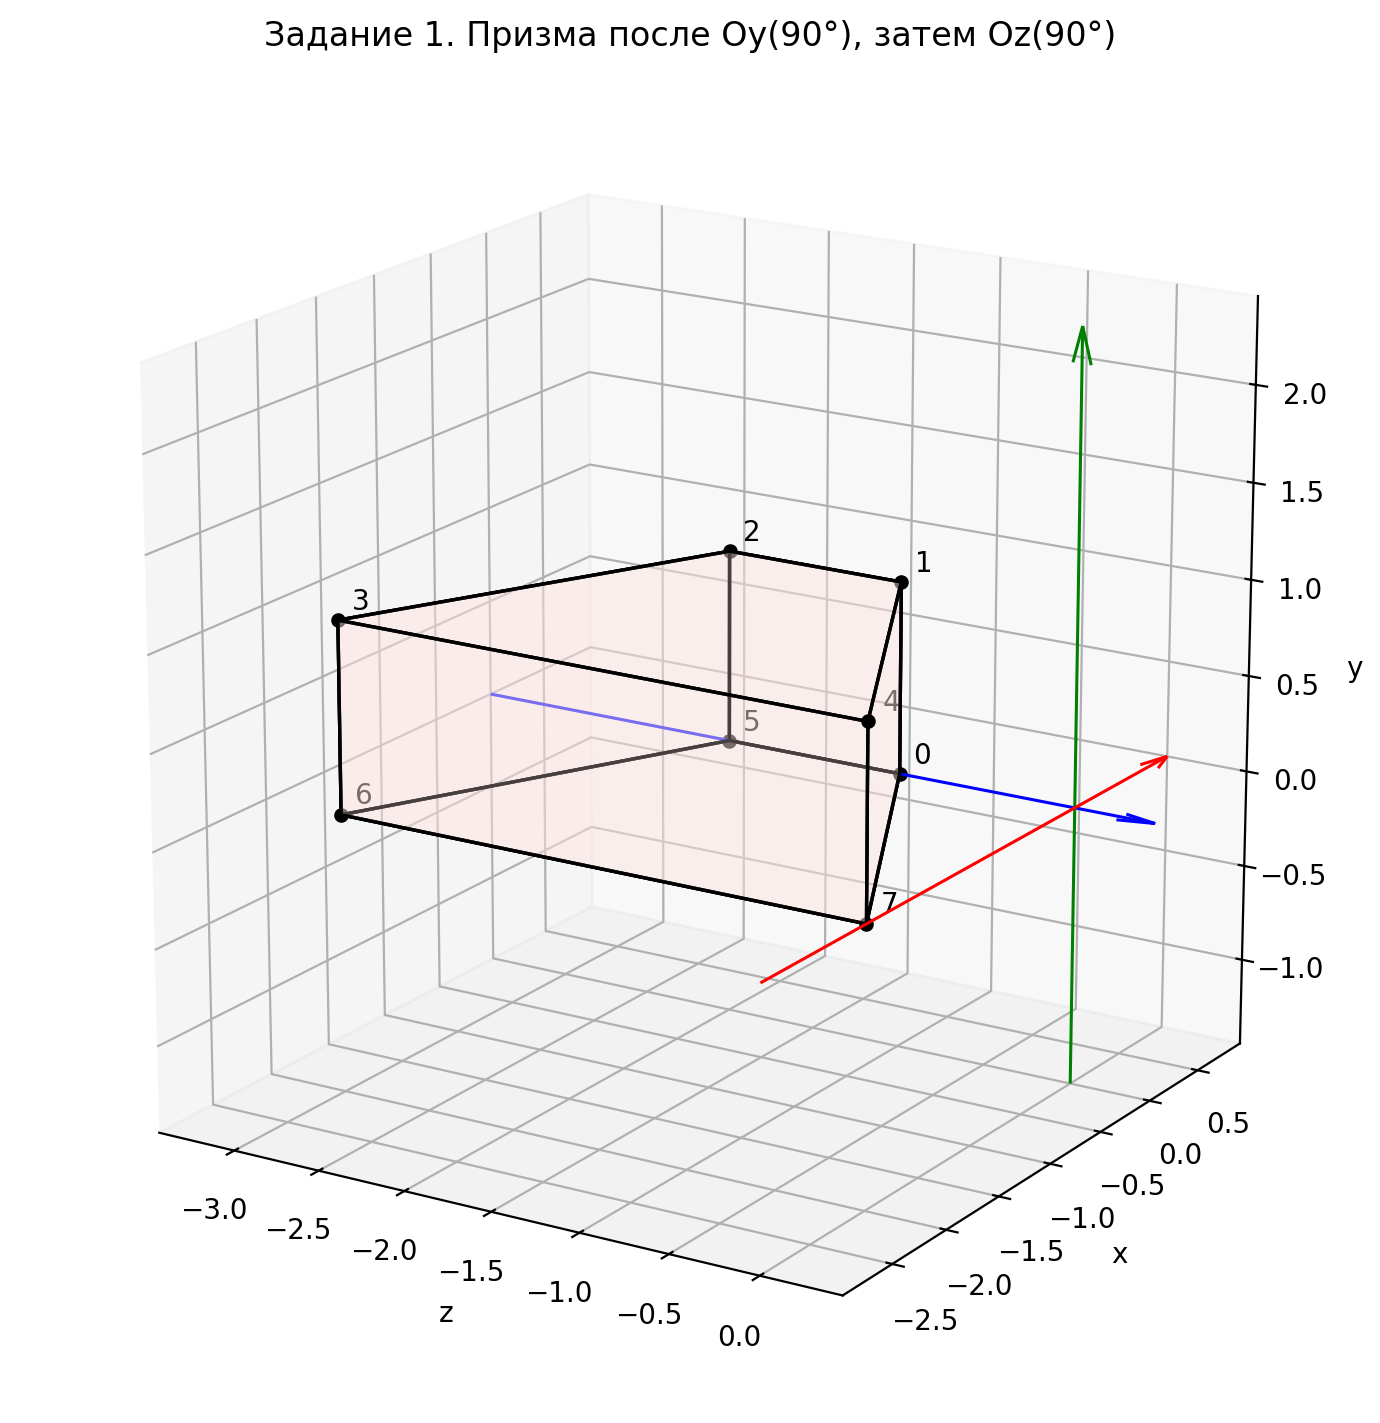

In [25]:
fig_prism_yz, ax_prism_yz, prism_yz_limits = make_3d_figure(
    prism_yz_manual,
    title="Задание 1. Призма после Oy(90°), затем Oz(90°)",
    elev=18,
    azim=-58,
)
add_polyhedron(ax_prism_yz, prism_yz_manual, PRISM_FACES, facecolor="mistyrose", edgecolor="black", alpha=0.28)
annotate_vertices(ax_prism_yz, prism_yz_manual)
fig_prism_yz


## Задание 2. Пирамида и формула Родрига

В матричной форме формула Родрига имеет вид

$$
R(\theta, \mathbf{a}) = I + \sin\theta\,[\mathbf{a}]_\times + (1 - \cos\theta)\,[\mathbf{a}]_\times^2,
$$

где $\mathbf{a}$ — единичный вектор оси вращения, а $\theta$ — угол вращения.

Геометрический смысл параметров:

- $\theta$ задает величину поворота;
- $\mathbf{a}$ задает направление оси вращения по правилу правой руки;
- компонента точки вдоль оси сохраняется, а перпендикулярная составляющая поворачивается в соответствующей плоскости.

Для переворота пирамиды вверх ногами достаточно повернуть ее вокруг оси $Ox$ на $180^\circ$,
а затем поднять на $2$ единицы вдоль оси $Oz$.


In [26]:
PYRAMID_VERTICES = np.array(
    [
        [-0.5, -0.5, 0.0],
        [0.5, -0.5, 0.0],
        [0.5, 0.5, 0.0],
        [-0.5, 0.5, 0.0],
        [0.0, 0.0, 0.71],
    ],
    dtype=np.float64,
)

PYRAMID_FACES = [
    [0, 1, 2, 3],
    [0, 1, 4],
    [1, 2, 4],
    [2, 3, 4],
    [3, 0, 4],
]

PYRAMID_FLIPPED_TABLE = np.array(
    [
        [-0.5, 0.5, 2.0],
        [0.5, 0.5, 2.0],
        [0.5, -0.5, 2.0],
        [-0.5, -0.5, 2.0],
        [0.0, 0.0, 1.29],
    ],
    dtype=np.float64,
)


In [27]:
pyramid_flip_matrix = rodrigues_matrix(axis=[1.0, 0.0, 0.0], angle_rad=np.pi)
pyramid_flipped = translate_points(apply_matrix(PYRAMID_VERTICES, pyramid_flip_matrix), shift=[0.0, 0.0, 2.0])

print("Координаты пирамиды после переворота и подъема:")
print(cleaned(pyramid_flipped))
print()
print("Разность с таблицей 12:")
print(cleaned(pyramid_flipped - PYRAMID_FLIPPED_TABLE, digits=10))


Координаты пирамиды после переворота и подъема:
[[-0.5   0.5   2.  ]
 [ 0.5   0.5   2.  ]
 [ 0.5  -0.5   2.  ]
 [-0.5  -0.5   2.  ]
 [ 0.    0.    1.29]]

Разность с таблицей 12:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


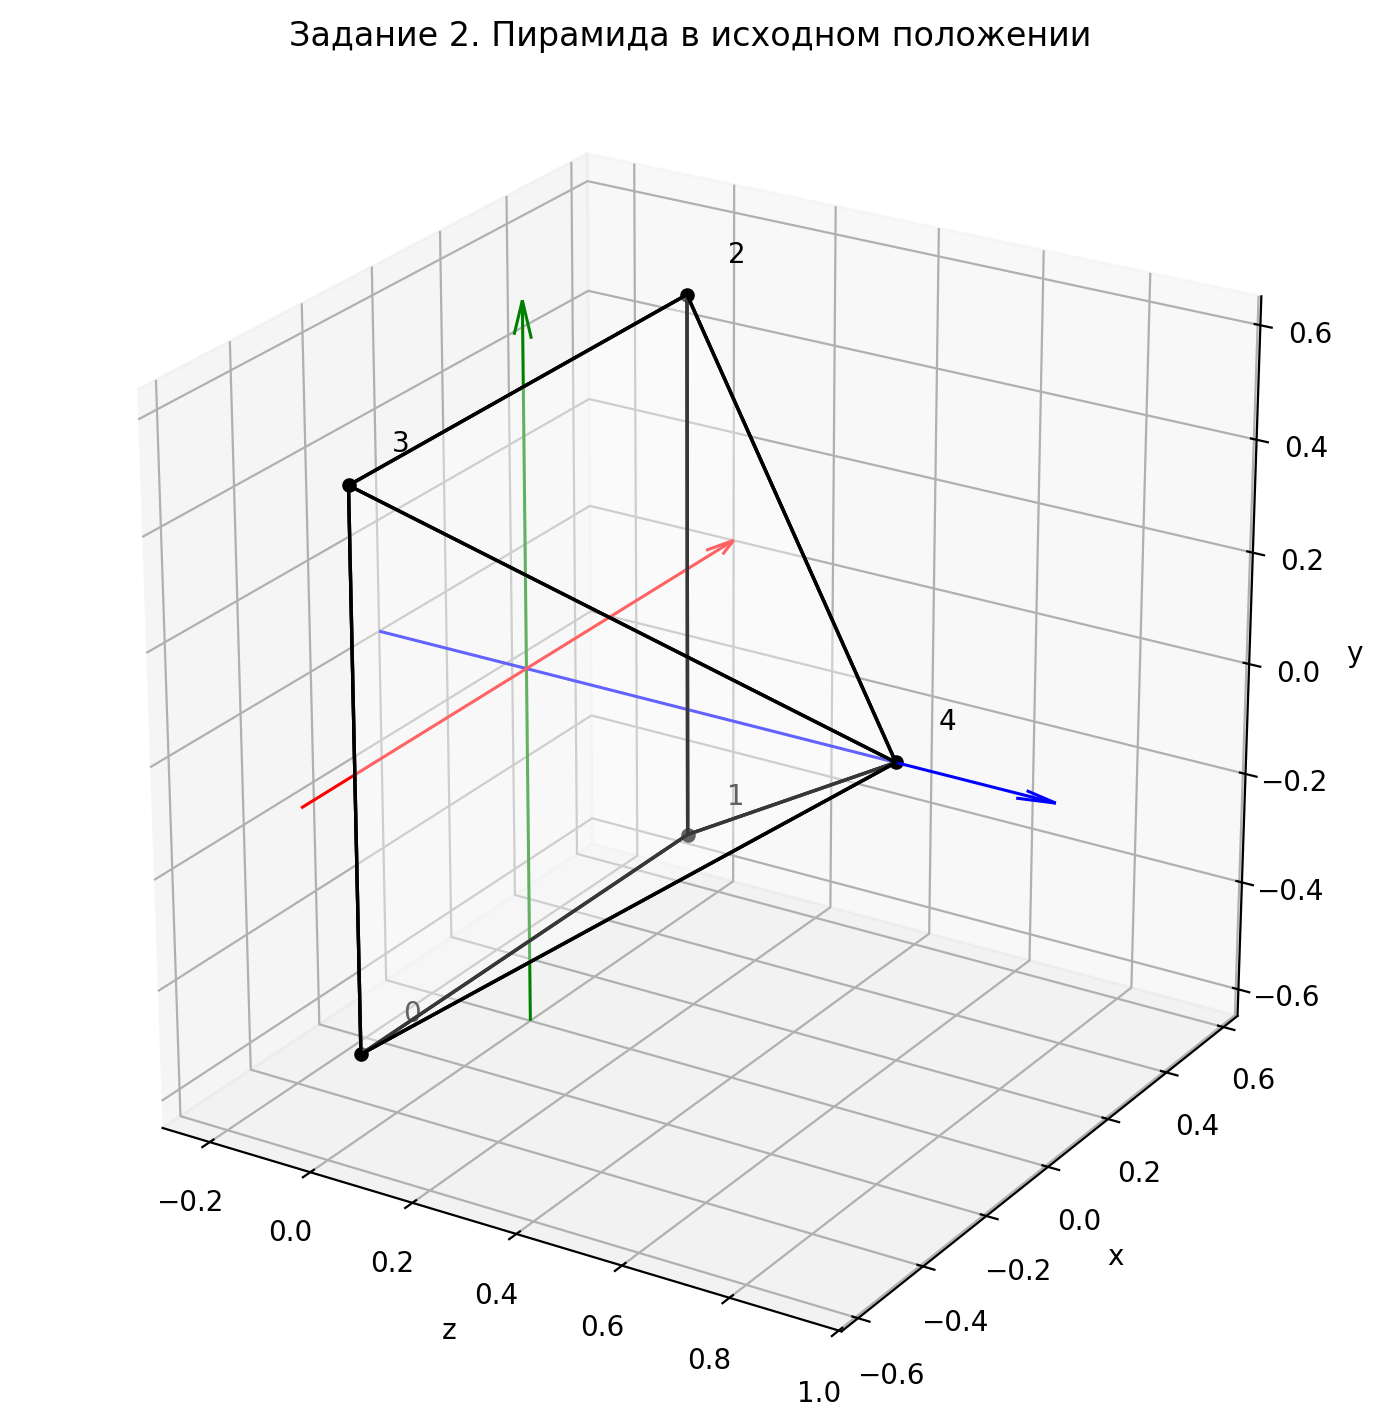

In [28]:
fig_pyramid_original, ax_pyramid_original, pyramid_limits = make_3d_figure(
    PYRAMID_VERTICES,
    title="Задание 2. Пирамида в исходном положении",
    elev=24,
    azim=-58,
)
add_polyhedron(ax_pyramid_original, PYRAMID_VERTICES, PYRAMID_FACES, facecolor="white", edgecolor="black", alpha=0.22)
annotate_vertices(ax_pyramid_original, PYRAMID_VERTICES)
fig_pyramid_original


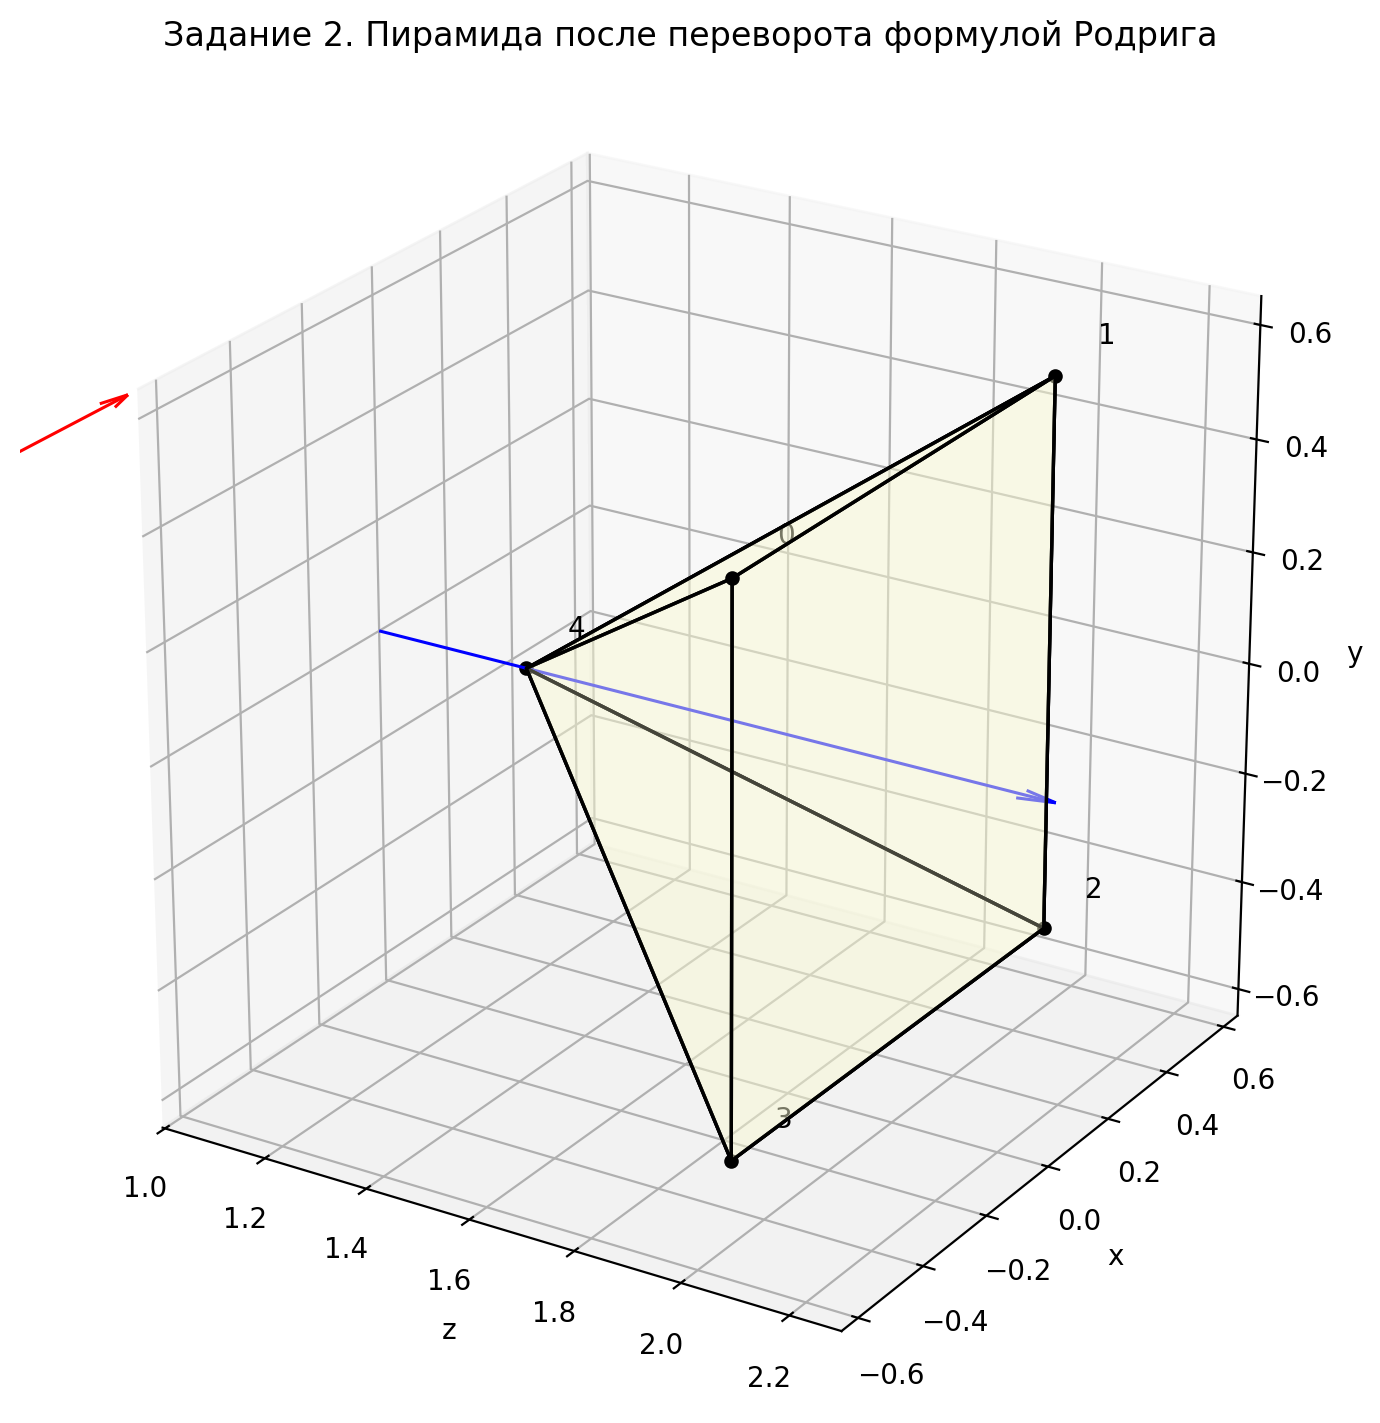

In [29]:
fig_pyramid_flipped, ax_pyramid_flipped, pyramid_flipped_limits = make_3d_figure(
    pyramid_flipped,
    title="Задание 2. Пирамида после переворота формулой Родрига",
    elev=24,
    azim=-58,
)
add_polyhedron(ax_pyramid_flipped, pyramid_flipped, PYRAMID_FACES, facecolor="lightgoldenrodyellow", edgecolor="black", alpha=0.28)
annotate_vertices(ax_pyramid_flipped, pyramid_flipped)
fig_pyramid_flipped


In [30]:
def plot_pyramid_rodrigues(angle_deg=180.0, shift_z=2.0):
    angle_rad = np.deg2rad(angle_deg)
    rotated = apply_matrix(PYRAMID_VERTICES, rodrigues_matrix(axis=[1.0, 0.0, 0.0], angle_rad=angle_rad))
    moved = translate_points(rotated, shift=[0.0, 0.0, shift_z])

    all_points = np.vstack([PYRAMID_VERTICES, moved])
    fig, ax, limits = make_3d_figure(
        all_points,
        title=f"Задание 2. Формула Родрига: угол = {angle_deg:.0f}°, сдвиг по Oz = {shift_z:.2f}",
        elev=24,
        azim=-58,
    )

    add_polyhedron(ax, PYRAMID_VERTICES, PYRAMID_FACES, facecolor="0.92", edgecolor="0.65", alpha=0.08)
    add_polyhedron(ax, moved, PYRAMID_FACES, facecolor="lightgoldenrodyellow", edgecolor="black", alpha=0.28)
    annotate_vertices(ax, moved)
    return fig


interactive_pyramid = interact(
    plot_pyramid_rodrigues,
    angle_deg=(0, 360, 1),
    shift_z=(-1.0, 3.0, 0.05),
)
pyramid_output = interactive_pyramid.widget.children[-1]
pyramid_output.layout.height = "780px"
interactive_pyramid


interactive(children=(IntSlider(value=180, description='angle_deg', max=360), FloatSlider(value=2.0, descripti…

<function __main__.plot_pyramid_rodrigues(angle_deg=180.0, shift_z=2.0)>

## Задание 3. Октаэдр, параметры Родрига-Гамильтона и кватернионы

Для параметров Родрига-Гамильтона используется формула

$$
\mathbf{p}' = \mathbf{p} + 2\lambda_0\,\boldsymbol{\lambda} \times \mathbf{p}
+ 2\,\boldsymbol{\lambda} \times (\boldsymbol{\lambda} \times \mathbf{p}),
\quad
\lambda_0 = \cos\frac{\theta}{2},
\quad
\boldsymbol{\lambda} = \sin\frac{\theta}{2}\,\mathbf{a}.
$$

Для кватернионов применяется сэндвич-формула

$$
p' = q p q^*,
\quad
q = \cos\frac{\theta}{2} + \sin\frac{\theta}{2}\,\mathbf{a}.
$$

Используемые определения:

- чистый кватернион — кватернион с нулевой скалярной частью;
- единичный кватернион — кватернион нормы $1$;
- сопряженный кватернион — кватернион с тем же скаляром и противоположной векторной частью;
- кватернионное умножение — некоммутативная операция, задающая композицию вращений.


In [31]:
OCTAHEDRON_VERTICES = np.array(
    [
        [-0.53, -0.85, 0.0],
        [0.85, -0.53, 0.0],
        [0.53, 0.85, 0.0],
        [-0.85, 0.53, 0.0],
        [0.0, 0.0, -1.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

OCTAHEDRON_FACES = [
    [0, 1, 5],
    [1, 2, 5],
    [2, 3, 5],
    [3, 0, 5],
    [1, 0, 4],
    [2, 1, 4],
    [3, 2, 4],
    [0, 3, 4],
]

AXIS_Y = np.array([0.0, 1.0, 0.0], dtype=np.float64)
AXIS_31 = normalize(OCTAHEDRON_VERTICES[1] - OCTAHEDRON_VERTICES[3])


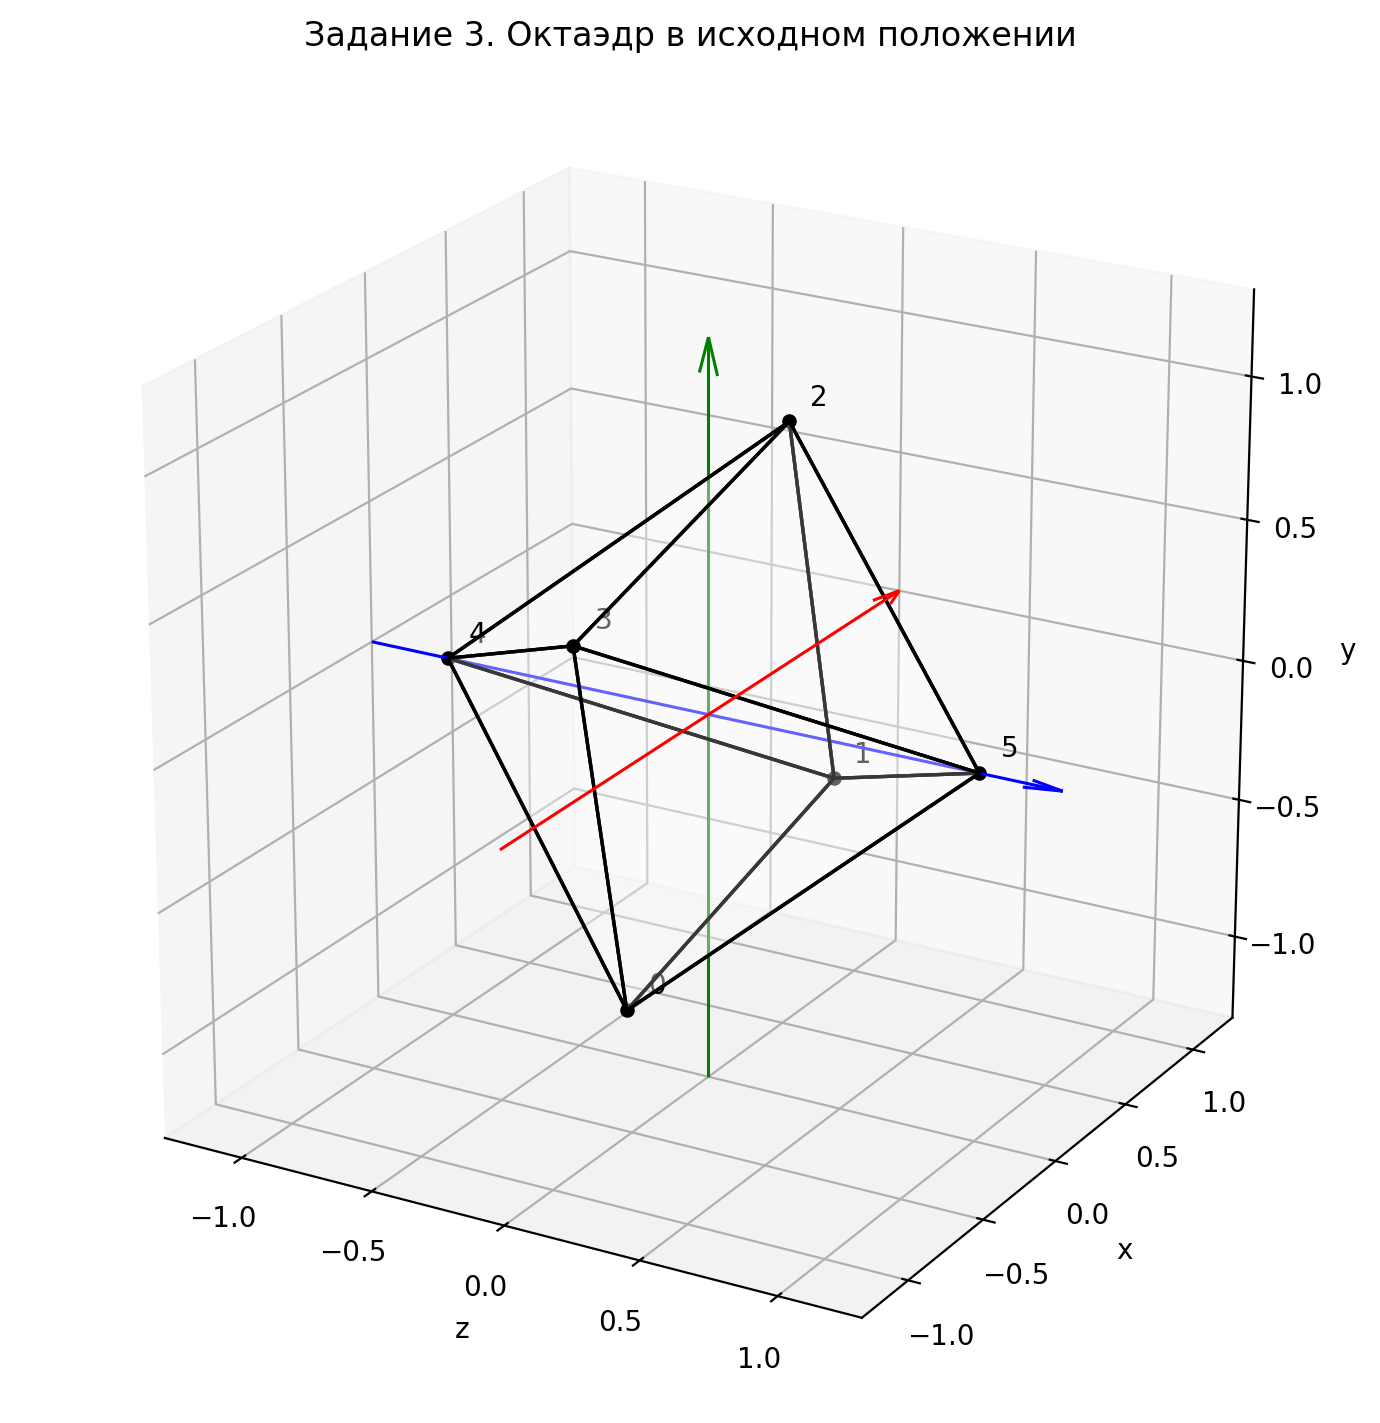

In [32]:
fig_octahedron, ax_octahedron, octa_limits = make_3d_figure(
    OCTAHEDRON_VERTICES,
    title="Задание 3. Октаэдр в исходном положении",
    elev=22,
    azim=-60,
)
add_polyhedron(ax_octahedron, OCTAHEDRON_VERTICES, OCTAHEDRON_FACES, facecolor="white", edgecolor="black", alpha=0.22)
annotate_vertices(ax_octahedron, OCTAHEDRON_VERTICES)
fig_octahedron


In [33]:
def plot_octahedron_rodrigues_hamilton(theta_deg=0.0):
    theta_rad = np.deg2rad(theta_deg)
    rotated = rotate_points_rodrigues_hamilton(OCTAHEDRON_VERTICES, axis=AXIS_Y, angle_rad=theta_rad)
    all_points = np.vstack([OCTAHEDRON_VERTICES, rotated])

    fig, ax, limits = make_3d_figure(
        all_points,
        title=f"Задание 3. Параметры Родрига-Гамильтона, вращение вокруг Oy: θ = {theta_deg:.0f}°",
        elev=22,
        azim=-60,
    )
    add_polyhedron(ax, OCTAHEDRON_VERTICES, OCTAHEDRON_FACES, facecolor="0.92", edgecolor="0.65", alpha=0.08)
    add_polyhedron(ax, rotated, OCTAHEDRON_FACES, facecolor="lavender", edgecolor="black", alpha=0.30)
    annotate_vertices(ax, rotated)
    draw_axis_line(ax, point=[0.0, 0.0, 0.0], direction=AXIS_Y, limits=limits, color="crimson", label="Oy")
    return fig


interactive_octa_rh = interact(
    plot_octahedron_rodrigues_hamilton,
    theta_deg=(0, 360, 1),
)
octa_rh_output = interactive_octa_rh.widget.children[-1]
octa_rh_output.layout.height = "780px"
interactive_octa_rh


interactive(children=(IntSlider(value=0, description='theta_deg', max=360), Output()), _dom_classes=('widget-i…

<function __main__.plot_octahedron_rodrigues_hamilton(theta_deg=0.0)>

In [34]:
def plot_octahedron_quaternion(theta_deg=0.0):
    theta_rad = np.deg2rad(theta_deg)
    rotated = rotate_points_quaternion(OCTAHEDRON_VERTICES, axis=AXIS_31, angle_rad=theta_rad)
    all_points = np.vstack([OCTAHEDRON_VERTICES, rotated])

    fig, ax, limits = make_3d_figure(
        all_points,
        title=f"Задание 3. Кватернионы, вращение вокруг оси 3→1: θ = {theta_deg:.0f}°",
        elev=22,
        azim=-60,
    )
    add_polyhedron(ax, OCTAHEDRON_VERTICES, OCTAHEDRON_FACES, facecolor="0.92", edgecolor="0.65", alpha=0.08)
    add_polyhedron(ax, rotated, OCTAHEDRON_FACES, facecolor="honeydew", edgecolor="black", alpha=0.30)
    annotate_vertices(ax, rotated)
    draw_axis_line(ax, point=[0.0, 0.0, 0.0], direction=AXIS_31, limits=limits, color="crimson", label="ось 3→1")
    return fig


interactive_octa_quat = interact(
    plot_octahedron_quaternion,
    theta_deg=(0, 360, 1),
)
octa_quat_output = interactive_octa_quat.widget.children[-1]
octa_quat_output.layout.height = "780px"
interactive_octa_quat


interactive(children=(IntSlider(value=0, description='theta_deg', max=360), Output()), _dom_classes=('widget-i…

<function __main__.plot_octahedron_quaternion(theta_deg=0.0)>

In [35]:
sample_angle_deg = 125.0
sample_angle_rad = np.deg2rad(sample_angle_deg)
octa_quat_manual = rotate_points_quaternion(OCTAHEDRON_VERTICES, axis=AXIS_31, angle_rad=sample_angle_rad)
octa_quat_scipy = Rotation.from_rotvec(sample_angle_rad * AXIS_31).apply(OCTAHEDRON_VERTICES)

print("Проверка кватернионного вращения на угле 125°.")
print("Максимальное отличие от SciPy:", np.max(np.abs(octa_quat_manual - octa_quat_scipy)))


Проверка кватернионного вращения на угле 125°.
Максимальное отличие от SciPy: 1.1102230246251565e-16


## Задание 4. Вращение вокруг внешней оси

В формулировке `04.pdf` есть опечатка: в задании 4 сказано «пирамиду из задания №3»,
хотя в задании 3 рассматривается октаэдр. По рисунку и смыслу работы здесь используется
пирамида из задания 2.

Ось вращения проходит через вершину №3 и параллельна оси $Oy$. Чтобы выполнить такое вращение,
удобно:

1. перенести вершину 3 в начало координат;
2. выполнить вращение вокруг направления $Oy$;
3. вернуть многогранник обратным переносом.


In [36]:
TASK4_AXIS_POINT = PYRAMID_VERTICES[3]
TASK4_AXIS_DIRECTION = np.array([0.0, 1.0, 0.0], dtype=np.float64)


def plot_pyramid_external_axis(angle_deg=0.0):
    angle_rad = np.deg2rad(angle_deg)
    rotated = rotate_about_axis_through_point(
        PYRAMID_VERTICES,
        axis_point=TASK4_AXIS_POINT,
        axis_direction=TASK4_AXIS_DIRECTION,
        angle_rad=angle_rad,
        method="rodrigues",
    )
    all_points = np.vstack([PYRAMID_VERTICES, rotated, TASK4_AXIS_POINT[None, :]])

    fig, ax, limits = make_3d_figure(
        all_points,
        title=f"Задание 4. Пирамида вокруг внешней оси: θ = {angle_deg:.0f}°",
        elev=24,
        azim=-58,
    )
    add_polyhedron(ax, PYRAMID_VERTICES, PYRAMID_FACES, facecolor="0.92", edgecolor="0.65", alpha=0.08)
    add_polyhedron(ax, rotated, PYRAMID_FACES, facecolor="peachpuff", edgecolor="black", alpha=0.30)
    annotate_vertices(ax, rotated)
    draw_axis_line(ax, point=TASK4_AXIS_POINT, direction=TASK4_AXIS_DIRECTION, limits=limits, color="crimson", label="внешняя ось")
    return fig


interactive_task4 = interact(
    plot_pyramid_external_axis,
    angle_deg=(0, 360, 1),
)
task4_output = interactive_task4.widget.children[-1]
task4_output.layout.height = "780px"
interactive_task4


interactive(children=(IntSlider(value=0, description='angle_deg', max=360), Output()), _dom_classes=('widget-i…

<function __main__.plot_pyramid_external_axis(angle_deg=0.0)>

## Вывод

В ноутбуке реализованы все способы вращения, перечисленные в лабораторной работе:

- композиция элементарных матриц Эйлера;
- матричная форма формулы Родрига;
- параметры Родрига-Гамильтона;
- кватернионное вращение;
- вращение вокруг внешней оси через перенос к началу координат и обратный перенос.

Для задания 1 численные проверки совпадают с таблицами из методички, а для ручных реализаций
дополнительно выполнена сверка со средствами `scipy.spatial.transform.Rotation`.
